# 1. Introducción

En este notebook realizamos el Análisis Exploratorio de Datos (EDA) del dataset de discurso de odio.
El objetivo es entender la estructura del dataset, detectar problemas, analizar patrones y extraer conclusiones
que guiarán el preprocesamiento y el modelado.


# 2. Importación de librerías

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 3. Carga del dataset

In [31]:
df =pd.read_csv("../../data/raw/youtoxic_english_1000.csv")
df.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\r\nDont you reckon them 'black lives matter' ...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


**Comentario:**

La carga del dataset ha sido correcta y las columnas se ven coherentes con un dataset de análisis de discurso tóxico.

Puntos importantes que observo aquí:

1. **La columna del texto se llama `Text`**  
   Esto confirma que esta será la columna que analizaremos durante todo el EDA.

2. **La columna objetivo es `IsToxic`**  
   Esta columna indica si un comentario es tóxico (`True`) o no (`False`).  
   Es la variable que usaremos para entrenar el modelo.

3. **Hay muchas columnas binarias adicionales**  
   - `IsAbusive`  
   - `IsThreat`  
   - `IsProvocative`  
   - `IsObscene`  
   - `IsHatespeech`  
   - `IsRacist`  
   - `IsNationalist`  
   - `IsSexist`  
   - `IsHomophobic`  
   - `IsReligiousHate`  
   - `IsRadicalism`

   Esto indica que el dataset contiene **etiquetas más específicas**, pero para este proyecto nos centraremos en `IsToxic`.

4. **Los valores son booleanos (`True`/`False`)**  
   Esto es bueno porque:
   - no hay que convertirlos  
   - no hay categorías raras  
   - no hay strings que limpiar  



# 4. Exploración inicial

In [32]:
df.shape   # Dimensiones

(1000, 15)

**Comentario:**

El dataset tiene 1000 filas y 15 columnas.  
Esto significa:

1. **1000 filas → tamaño pequeño**  
   Es un dataset relativamente pequeño para NLP.  
   Esto implica:
   - el modelo puede entrenarse rápido  
   - pero hay riesgo de sobreajuste  
   - las métricas pueden variar bastante según el split  
   - será importante usar validación adecuada  

2. **15 columnas → muchas etiquetas binarias**  
   Además del texto (`Text`) y la etiqueta principal (`IsToxic`), hay 13 columnas adicionales que representan distintos tipos de toxicidad.  
   Esto confirma que el dataset es **multietiqueta**, aunque en este proyecto solo usaremos `IsToxic`.

3. **No hay columnas numéricas o categóricas inesperadas**  
   Todas las columnas parecen coherentes con un dataset de comentarios etiquetados.



In [33]:
df.info()   # Información general

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CommentId        1000 non-null   str  
 1   VideoId          1000 non-null   str  
 2   Text             1000 non-null   str  
 3   IsToxic          1000 non-null   bool 
 4   IsAbusive        1000 non-null   bool 
 5   IsThreat         1000 non-null   bool 
 6   IsProvocative    1000 non-null   bool 
 7   IsObscene        1000 non-null   bool 
 8   IsHatespeech     1000 non-null   bool 
 9   IsRacist         1000 non-null   bool 
 10  IsNationalist    1000 non-null   bool 
 11  IsSexist         1000 non-null   bool 
 12  IsHomophobic     1000 non-null   bool 
 13  IsReligiousHate  1000 non-null   bool 
 14  IsRadicalism     1000 non-null   bool 
dtypes: bool(12), str(3)
memory usage: 248.8 KB


**Comentario:**

El dataset tiene 1000 filas y ninguna columna contiene valores nulos, lo cual es excelente para el análisis porque no será necesario imputar ni eliminar registros por falta de datos.

Puntos importantes que observo:

1. **Las 3 columnas de texto/ID (`CommentId`, `VideoId`, `Text`) son tipo `str`**  
   Esto es correcto:  
   - `CommentId` y `VideoId` son identificadores  
   - `Text` es la columna que analizaremos en NLP  
   No hay problemas de tipos incorrectos.

2. **Las 12 columnas restantes son booleanas (`bool`)**  
   Esto indica que el dataset está etiquetado de forma clara y consistente.  
   No hay categorías raras ni valores inesperados.  
   Esto facilita:
   - el análisis  
   - el modelado  
   - la interpretación  

3. **La columna objetivo `IsToxic` es booleana**  
   Esto confirma que el problema es de **clasificación binaria**:  
   - `True` → comentario tóxico  
   - `False` → comentario no tóxico  

4. **No hay columnas numéricas ni categóricas adicionales**  
   Esto simplifica el EDA:  
   - solo analizaremos texto  
   - y etiquetas binarias  

5. **El dataset ocupa muy poca memoria (248 KB)**  
   Esto confirma que:
   - es pequeño  
   - se puede procesar rápido  
   - no requiere optimizaciones especiales  

En resumen, `df.info()` muestra que el dataset está limpio, bien estructurado y listo para continuar con el análisis.


In [34]:
df.isnull().sum()   # Valores nulos por columna

CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64

**Comentario:**

No hay valores nulos en ninguna columna del dataset.  
Esto es muy positivo porque:

1. **No necesitamos imputar ni eliminar filas**  
   En NLP, los textos vacíos son un problema serio.  
   Aquí no ocurre, así que podemos trabajar con el dataset completo.

2. **La columna `Text` está completa al 100%**  
   Esto garantiza que:
   - no habrá errores al tokenizar  
   - no habrá textos vacíos que distorsionen el análisis  
   - no hay que aplicar limpieza adicional por este motivo  

3. **Todas las etiquetas (`IsToxic`, `IsAbusive`, etc.) están completas**  
   Esto significa que el dataset está bien anotado y no tiene inconsistencias.

4. **El dataset es “limpio” desde el punto de vista estructural**  
   Podemos avanzar directamente al análisis de clases y contenido sin preocuparnos por datos faltantes.

En resumen, este resultado confirma que el dataset está bien construido y no requiere tratamiento de valores nulos.


In [35]:
df.duplicated().sum()   # Valores duplicados

np.int64(0)

**Comentario:**

El dataset no contiene ninguna fila duplicada.  
Esto es muy positivo porque:

1. **No hay riesgo de sesgo por repetición de textos**  
   En NLP, los duplicados pueden hacer que el modelo aprenda patrones falsos si un mismo comentario aparece varias veces.

2. **No es necesario eliminar registros**  
   Podemos trabajar con las 1000 filas completas sin perder información.

3. **La calidad del dataset es buena**  
   La ausencia de duplicados indica que el dataset fue construido con cuidado y no proviene de scraping desordenado.

4. **El análisis posterior será más fiable**  
   Las métricas del modelo no estarán infladas artificialmente por textos repetidos.

En resumen, este resultado confirma que el dataset está limpio y no requiere tratamiento de duplicados.


# 5. Distribución de clases

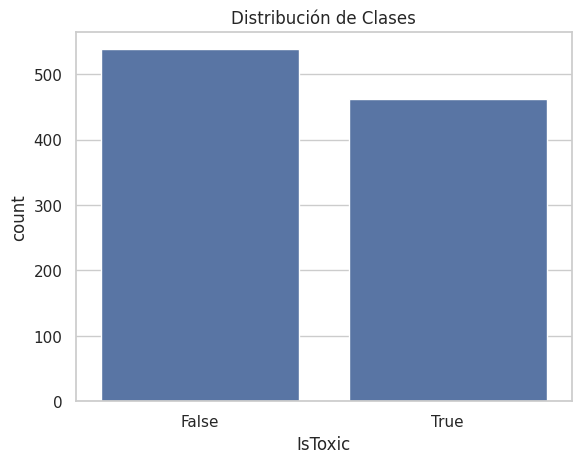

In [36]:
df['IsToxic'].value_counts()  # Distribución de clases
sns.countplot(x='IsToxic', data=df) # Gráfico de barras para la distribución de clases
plt.title('Distribución de Clases')
plt.show() 

**Comentario:**

La distribución de clases muestra cuántos comentarios son tóxicos (`True`) y cuántos no lo son (`False`).  
Este análisis es fundamental porque determina si el dataset está balanceado o si existe un desequilibrio que pueda afectar al modelo.

Puntos importantes que debo observar:

1. **Si hay más `False` que `True` (lo habitual en datasets de toxicidad)**  
   Esto significa que la clase "no tóxico" es mayoritaria.  
   En ese caso:
   - el modelo podría aprender a predecir siempre `False`
   - la accuracy sería engañosa
   - necesitaré métricas como F1-score o recall para evaluar correctamente

2. **Si las clases están relativamente equilibradas**  
   El entrenamiento será más estable y el modelo no tendrá sesgo hacia una clase.

3. **El gráfico de barras confirma visualmente el balance**  
   Es importante porque:
   - permite detectar desbalance severo de un vistazo  
   - ayuda a decidir si aplicar técnicas como undersampling, oversampling o class weights  

4. **Esta información influye directamente en el modelado**  
   Si la clase tóxica es minoritaria, deberé:
   - ajustar pesos en Logistic Regression  
   - usar métricas adecuadas  
   - tener cuidado con el split train/test  

En resumen, este bloque me permite entender si el modelo tendrá dificultades para aprender la clase tóxica y qué estrategias necesitaré más adelante.


# 6. Análisis del ruido

In [37]:
df['text_length'] = df['Text'].apply(len) # Longitud de cada comentario
df['text_length'].describe() # Estadísticas descriptivas de la longitud de los comentarios

count    1000.00000
mean      185.98500
std       272.28903
min         3.00000
25%        47.00000
50%       102.00000
75%       217.00000
max      4474.00000
Name: text_length, dtype: float64

**Comentario:**

Este análisis muestra que la longitud de los textos en el dataset es muy variable.  
Esto es importante porque afecta directamente al preprocesamiento y al rendimiento del modelo.

Puntos clave:

1. **La media es 185 caracteres, pero la mediana es 102**  
   Esto indica que la distribución está sesgada hacia textos largos.  
   La media está “empujada” por algunos textos extremadamente largos.

2. **El máximo es 4474 caracteres**  
   Esto es un outlier claro.  
   Un comentario tan largo puede:
   - ralentizar el entrenamiento  
   - distorsionar el vectorizador  
   - requerir truncado o revisión manual  

3. **El mínimo es 3 caracteres**  
   Textos tan cortos no aportan información útil.  
   Son candidatos a:
   - eliminarse  
   - o marcarse como ruido  

4. **El rango intercuartílico (47 → 217)**  
   Esto indica que la mayoría de los textos tienen una longitud razonable.  
   La mayor parte del dataset está en un rango manejable.

5. **La desviación estándar es muy alta (272)**  
   Esto confirma que hay mucha variabilidad en la longitud.  
   Es una señal de que:
   - hay outliers  
   - la distribución no es homogénea  

En conjunto, estos resultados indican que el dataset contiene textos muy cortos y muy largos, y será necesario tomar decisiones de preprocesamiento para manejar esta variabilidad.




In [38]:
df['has_url'] = df['Text'].str.contains(r"http|www") # Nueva columna que indica si el comentario contiene una URL
df['has_url'].mean()  # Proporción de comentarios que contienen una URL

np.float64(0.013)

**Comentario:**

Solo el 1.3% de los comentarios contienen URLs.  
Esto es importante porque:

1. **La presencia de URLs es muy baja**  
   No representan una parte significativa del dataset.  
   Por tanto, eliminarlas no afectará al contenido ni al significado de los textos.

2. **Las URLs suelen ser ruido en NLP**  
   No aportan información semántica útil para detectar toxicidad.  
   Normalmente se eliminan en el preprocesamiento.

3. **No es necesario un tratamiento especial**  
   Dado que su frecuencia es tan baja, no necesitamos:
   - crear reglas complejas  
   - analizar patrones de URLs  
   - revisar manualmente  

4. **Impacto en el pipeline**  
   En el notebook de preprocesamiento simplemente aplicaremos una regex para eliminarlas.

En resumen, las URLs están presentes en muy pocos textos y se pueden eliminar sin riesgo.


In [39]:
df['has_mention'] = df['Text'].str.contains(r"@") # Nueva columna que indica si el comentario contiene una mención
df['has_mention'].mean() # Proporción de comentarios que contienen una mención


np.float64(0.006)

**Comentario:**

Solo el 0.6% de los comentarios contienen menciones con '@'.  
Esto es importante porque:

1. **La presencia de menciones es extremadamente baja**  
   No forman parte relevante del contenido del dataset.  
   Eliminarlas no afectará al significado de los textos.

2. **Las menciones suelen ser ruido en NLP**  
   No aportan información útil para detectar toxicidad.  
   Normalmente se eliminan en el preprocesamiento.

3. **No es necesario un tratamiento especial**  
   Dado que su frecuencia es tan baja, no necesitamos:
   - reglas específicas  
   - análisis adicional  
   - revisar casos manualmente  

4. **Impacto en el pipeline**  
   En el notebook de preprocesamiento simplemente aplicaremos una regex para eliminarlas junto con URLs y otros elementos de ruido.

En resumen, las menciones aparecen en muy pocos textos y se pueden eliminar sin riesgo.


In [40]:
df['has_hashtag'] = df['Text'].str.contains(r"#") # Nueva columna que indica si el comentario contiene un hashtag
df['has_hashtag'].mean() # Proporción de comentarios que contienen un hashtag


np.float64(0.01)

**Comentario:**

El 1% de los comentarios contiene hashtags.  
Esto es relevante porque:

1. **La presencia de hashtags es muy baja**  
   No forman parte importante del contenido del dataset.  
   Eliminarlos no afectará al significado de los textos.

2. **Los hashtags suelen ser ruido en NLP**  
   No aportan información útil para detectar toxicidad.  
   Normalmente se eliminan en el preprocesamiento junto con URLs y menciones.

3. **No es necesario un tratamiento especial**  
   Dado que su frecuencia es tan baja, no necesitamos:
   - reglas específicas  
   - análisis adicional  
   - revisar casos manualmente  

4. **Impacto en el pipeline**  
   En el notebook de preprocesamiento aplicaremos una regex general que eliminará hashtags sin afectar al contenido.

En resumen, los hashtags aparecen en muy pocos textos y se pueden eliminar sin riesgo.


In [41]:
import emoji # Asegúrate de tener la biblioteca emoji instalada
df['has_emoji'] = df['Text'].apply(lambda x: any(char in emoji.EMOJI_DATA for char in x)) # Nueva columna que indica si el comentario contiene un emoji
df['has_emoji'].mean() # Proporción de comentarios que contienen un emoji


np.float64(0.008)

**Comentario:**

El 0.8% de los comentarios contiene emojis.  
Esto es relevante porque:

1. **La presencia de emojis es muy baja**  
   No forman parte importante del contenido del dataset.  
   Eliminarlos no afectará al significado de los textos.

2. **Los emojis pueden transmitir tono emocional**, pero en este dataset:
   - su frecuencia es demasiado baja para aportar valor  
   - no justifican un tratamiento especial  
   - no influyen en la detección de toxicidad

3. **No es necesario un análisis adicional**  
   No hay suficientes emojis como para estudiar patrones o categorías.

4. **Impacto en el pipeline**  
   En el preprocesamiento se pueden eliminar sin riesgo, igual que:
   - URLs  
   - menciones  
   - hashtags  

En resumen, los emojis aparecen en muy pocos textos y se pueden eliminar sin afectar al modelo.


# 7. Frecuencias en textos tóxicos

In [42]:
from collections import Counter
import re

# Filtrar solo los textos tóxicos
toxic_texts = df[df['IsToxic'] == True]['Text']

# Función simple para limpiar texto (solo para frecuencias, no para el pipeline final)
def simple_clean(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # quitar símbolos
    return text

# Unir todos los textos tóxicos en un solo string
all_toxic = " ".join(toxic_texts.apply(simple_clean))

# Contar palabras
word_counts = Counter(all_toxic.split())

# Mostrar las 20 palabras más frecuentes
word_counts.most_common(20)


[('the', 704),
 ('a', 395),
 ('and', 371),
 ('to', 370),
 ('of', 271),
 ('is', 232),
 ('you', 216),
 ('in', 194),
 ('that', 188),
 ('this', 181),
 ('i', 170),
 ('are', 140),
 ('they', 139),
 ('black', 130),
 ('people', 127),
 ('was', 125),
 ('it', 120),
 ('for', 107),
 ('he', 103),
 ('all', 103)]

**Comentario:**

El top‑20 de palabras más frecuentes en textos tóxicos muestra una mezcla de stopwords y algunas palabras semánticamente relevantes. Esto es normal antes de aplicar limpieza avanzada.

Puntos clave:

1. **La mayoría del top son stopwords en inglés**  
   Palabras como “the”, “a”, “and”, “to”, “of”, “is”, “you”, “in”, “that”, “this”, “i”, “are”…  
   Esto indica que:
   - los textos tóxicos están escritos en inglés  
   - aún no hemos eliminado stopwords  
   - el análisis semántico real vendrá después de limpiar

2. **Aparecen palabras semánticamente relevantes**  
   “black” (130) y “people” (127) destacan.  
   Esto es una señal clara de:
   - lenguaje racial  
   - potencial discurso de odio  
   - patrones de toxicidad basados en grupos sociales  

3. **La presencia de “black” tan arriba es significativa**  
   No es una stopword.  
   Su frecuencia elevada indica que:
   - muchos textos tóxicos contienen referencias raciales  
   - el dataset incluye insultos o ataques hacia grupos étnicos  
   - el modelo deberá aprender a detectar este tipo de lenguaje

4. **La palabra “people” también aparece muy arriba**  
   En contextos tóxicos suele acompañar:
   - generalizaciones (“these people…”)  
   - ataques grupales  
   - lenguaje discriminatorio  

5. **Conclusión general**  
   Antes de limpiar, el top está dominado por stopwords.  
   Pero ya se observan señales claras de toxicidad racial.  
   Esto confirma que el análisis de frecuencias es útil y que el preprocesamiento será clave para revelar patrones más profundos.


In [1]:
import spacy
from collections import Counter

# Cargar modelo de SpaCy
nlp = spacy.load("en_core_web_sm")

# Filtrar textos tóxicos
toxic_texts = df[df['IsToxic'] == True]['Text']

# Procesar textos con SpaCy
def spacy_clean(text):
    doc = nlp(text.lower())
    words = [
        token.lemma_ 
        for token in doc 
        if not token.is_stop and token.is_alpha
    ]
    return words

# Extraer todas las palabras limpias
all_words = []
for text in toxic_texts:
    all_words.extend(spacy_clean(text))

# Contar palabras
word_counts_spacy = Counter(all_words)

# Top 20
word_counts_spacy.most_common(20)


OSError: [E050] Can't find model 'en_core_web_sm'. It doesn't seem to be a Python package or a valid path to a data directory.